### 1. Library Imports

Importing the necessary libraries for data manipulation, visualization, and numerical operations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Data Loading

Loading the 'GlobalPharma Dataset.ods' file into a pandas DataFrame.

In [ ]:
pip install odfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160673 sha256=b46a351eee158c214d371edb1c438b841e4ec52be63df4765ff1740f4278cb03
  Stored in directory: /root/.cache/pip/wheels/36/5d/63/8243a7ee78fff0f944d638fd0e66d7278888f5e2285d7346b6
Successfully built odfpy


In [ ]:
df = pd.read_excel('GlobalPharma Dataset.ods', engine='odf')

### 3. Basic Data Cleaning

Now we are going to handle missing values in 'Phase_II_Patient_Count' by imputing with the column's mean.

In [ ]:
df['Phase_II_Patient_Count'] = df['Phase_II_Patient_Count'].fillna(df['Phase_II_Patient_Count'].mean())

### 4. Quick Data Inspection

After handling potential missing vlaues we will check our work. This will be done by displayng the head, info, value counts of 'Regulatory_Status', and descriptive statistics to get an overview of the dataset.

In [ ]:
print(df.head())
print(df.info())
print(df['Regulatory_Status'].value_counts())
print(df.describe())

   Week  Phase_II_Patient_Count  Success_Metric_Score  Weekly_R&D_Spend  \
0     1              200.000000                  0.72           2500000   
1     2              205.000000                  0.71           2450000   
2     3              210.000000                  0.74           2600000   
3     4              215.000000                  0.68           2750000   
4     5              386.078431                  0.65           2800000   

   Compliance_Audit_Score Regulatory_Status  
0                      95         Compliant  
1                      94         Compliant  
2                      92         Compliant  
3                      88           Warning  
4                      85           Warning  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Week                    52 non-null     int64  
 1   Phase_I

### 5. Numerical Feature Distributions

The next step is visualization. The code below will allow us to visualize the distributions of key numerical features through an histograms to better understand their spread and characteristics.

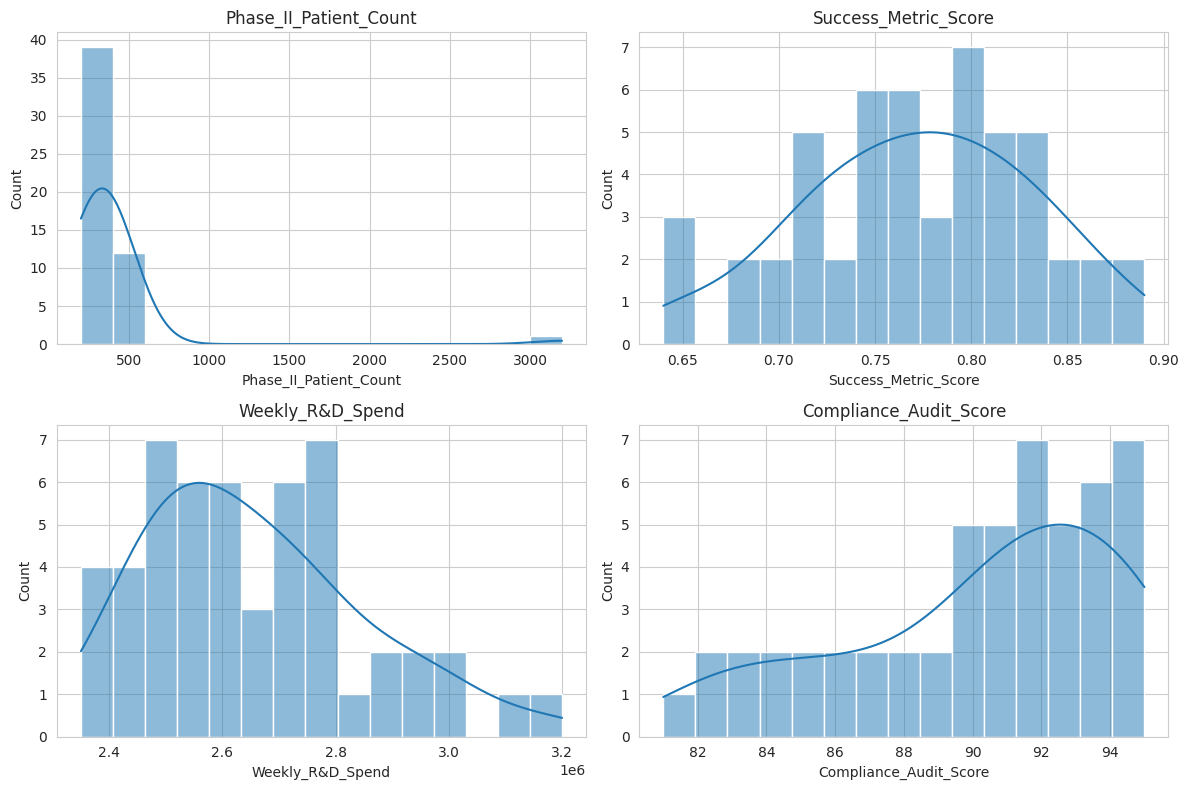

In [ ]:
sns.set_style("whitegrid")
cols = [
    'Phase_II_Patient_Count',
    'Success_Metric_Score',
    'Weekly_R&D_Spend',
    'Compliance_Audit_Score'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, bins=15, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### 6. Financial Model Parameters

Similarly to our manual calculation, in the next cell we are simply going to transalte our former logic into a set of instructions for python to perform that very same logic.

We are going to define the probabilities and financial values used in the investment analysis.

In [ ]:
p2 = 0.40 # Phase II success rate
p3 = 0.60 # Phase III success rate
reg = 0.90 # Regulatory approval rate
value = 1.2e9 # Drug value if marketed ($1.2 Billion)
investment = 150e6 # Additional investment ($150 Million)

### 7. Current Expected Value Calculation

Calculating the expected value of the drug based on current success probabilities without the additional investment.

In [ ]:
p_success = p2 * p3 * reg # Overall probability of success
ev_current = p_success * value # Current expected value

### 8. Break-Even Analysis

Determining the required Phase II success rate increase to break even on the additional investment.

In [ ]:
target_ev = ev_current + investment # Target expected value to break even
p2_break_even = target_ev / (p3 * reg * value) # Required Phase II rate for break-even
delta = (p2_break_even - p2) * 100 # Required percentage point increase

### 9. Print Financial Results

The cell below shows exactly the success rate necessary in Phase II for the green light on the investment.

Summary:

Displaying the calculated current expected value, break-even Phase II rate, and the required increase.

In [ ]:
print(f"Current Expected Value: ${ev_current:,.0f}")
print(f"Break-even Phase II rate: {p2_break_even:.2%}")
print(f"Required increase in Phase II success rate: {delta:.2f} percentage points")

Current Expected Value: $259,200,000
Break-even Phase II rate: 63.15%
Required increase in Phase II success rate: 23.15 percentage points


### 10. Visualization of Success Rates

Comparing the current and break-even Phase II success rates visually using a bar plot.

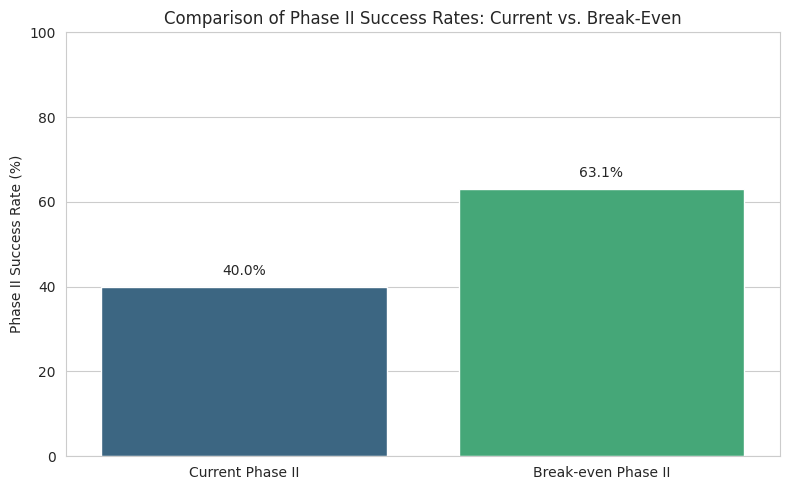

In [ ]:
labels = ["Current Phase II", "Break-even Phase II"]
values = [p2 * 100, p2_break_even * 100] # Convert to percentage

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=labels, y=values, hue=labels, palette='viridis', legend=False, ax=ax)
ax.set_ylabel("Phase II Success Rate (%)")
ax.set_ylim(0, 100)
ax.set_title("Comparison of Phase II Success Rates: Current vs. Break-Even")

for i, v in enumerate(values):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", va='bottom')

plt.tight_layout()
plt.show()

### 11. Final Recommendation

Providing a clear recommendation based on the break-even analysis.

In [ ]:
print("\nRecommendation:")
if delta <= 0:
    print("The investment is already profitable or breaks even with no increase required.")
else:
    print(f"Proceed only if Phase II success can increase by ~{delta:.2f} percentage points (from {p2:.2%} to {p2_break_even:.2%}).")
    print("A thorough assessment of the feasibility and risk associated with achieving this specific increase is crucial before making a decision.")


Recommendation:
Proceed only if Phase II success can increase by ~23.15 percentage points (from 40.00% to 63.15%).
A thorough assessment of the feasibility and risk associated with achieving this specific increase is crucial before making a decision.


### First Summary of Findings

*   **Financial Model Parameters:**
    *   Phase II success rate (p2): 40%
    *   Phase III success rate (p3): 60%
    *   Regulatory approval rate (reg): 90%
    *   Drug value if marketed (value):
    $1.2 Billion
    *   Additional investment: $150 Million

*   **Current Expected Value:** $259,200,000

*   **Break-Even Analysis:**
    *   To break even on the $150 Million investment, the Phase II success rate must increase from 40% to **63.15%**.
    *   This represents a required increase of **23.15 percentage points**.

*   **Recommendation:** Proceed with the investment only if a thorough assessment confirms the feasibility of increasing the Phase II success rate by approximately 23.15 percentage points.